In [ ]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
import math
import sys
from scipy.ndimage import label
from scipy.spatial import cKDTree
from PIL import Image
np.set_printoptions(threshold=sys.maxsize)
from scipy.interpolate import splprep, splev

In [7]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
    return images

In [8]:
pics = np.zeros(shape=(7, 256, 256, 3))
pics = load_images_from_folder('C:\\Users\\2020\\Documents\\3 Academics\\Cambridge\\Publications\\Computer Vision\\Figures and Original Soln\\pics')

In [9]:
img1 = pics[-2].astype('uint8')
img1[2][2] = 50; img1[2][6] = 0; img1[3][2] = 50; img1[3][3] = 50; img1[3][4] = 50; img1[3][5] = 50; img1[4][2] = 50; img1[4][4] = 0
img1[4][5] = 50; img1[4][6] = 50; img1[5][2] = 50; img1[5][3] = 50; img1[5][4] = 50; img1[5][5] = 50; img1[5][6] = 50

img2 = pics[-2].astype('uint8')
img2[2][2] = 50; img2[2][6] = 0; img2[3][2] = 50; img2[3][3] = 50; img2[3][4] = 50; img2[3][5] = 50; img2[4][2] = 50; img2[4][4] = 0
img2[4][5] = 50; img2[4][6] = 50; img2[5][2] = 50; img2[5][3] = 50; img2[5][4] = 50; img2[5][5] = 50; img2[5][6] = 50
img2[0][0] = [255,255,60]; img2[0][1] = [255,255,60]; img2[0][2] = [255,255,60];   img2[0][3] = [255,255,60]; img2[0][4] = [255,255,60]
img2[0][5] = [255,255,60]; img2[0][6] = [255,255,60]; img2[0][7] = [255,255,60]; img2[7][0] = [255,255,60]; img2[7][1] = [255,255,60]
img2[7][2] = [255,255,60]; img2[7][3] = [255,255,60]; img2[7][4] = [255,255,60]; img2[7][5] = [255,255,60]; img2[7][6] = [255,255,60]
img2[7][7] = [255,255,60]; img2[1][0] = [255,255,60]; img2[2][0] = [255,255,60]; img2[3][0] = [255,255,60]; img2[4][0] = [255,255,60]
img2[5][0] = [255,255,60]; img2[6][0] = [255,255,60]; img2[1][7] = [255,255,60]; img2[2][7] = [255,255,60]; img2[3][7] = [255,255,60]
img2[4][7] = [255,255,60]; img2[5][7] = [255,255,60]; img2[6][7] = [255,255,60]; img2[1][1] = [255,255,60]; img2[2][1] = [255,255,60]
img2[3][1] = [255,255,60]; img2[4][1] = [255,255,60]; img2[5][1] = [255,255,60]; img2[6][1] = [255,255,60]; img2[6][2] = [255,255,60]
img2[6][3] = [255,255,60]; img2[6][4] = [255,255,60]; img2[6][5] = [255,255,60]; img2[6][6] = [255,255,60]; img2[6][7] = [255,255,60]
img2[3][6] = [60,255,255]
#f, axarr = plt.subplots(1,2)
#axarr[0].imshow(img1[...,::-1])
#axarr[1].imshow(img2[...,::-1])

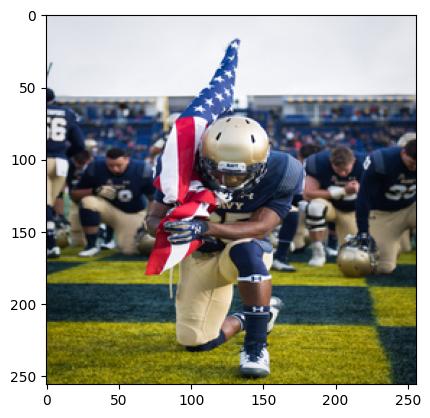

In [ ]:
chosenImage = pics[10]

#HYPERPARAMETERS
thresh = 0.25               # color similarity threshold
percentMerge = 0.1          # minimum cluster size as % of image

# Color diversity score from HSV quantized bins
hsv = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2HSV)

# Quantize channels
h_bin = (hsv[:, :, 0] // 12).astype(np.int32) 
s_bin = (hsv[:, :, 1] // 32).astype(np.int32)   
v_bin = (hsv[:, :, 2] // 32).astype(np.int32)  

key = h_bin * 64 + s_bin * 8 + v_bin
unique_colors = np.unique(key).size

if unique_colors < 75:
    pyrLevels = 1
elif unique_colors < 200:
    pyrLevels = 2
else:
    pyrLevels = 3

# Convert BGR to RGB for PIL (PIL expects RGB format)
chosenImageRGB = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
im = Image.fromarray(chosenImageRGB)
im.save('test.png')
im.save('test.jpg')
im.save('test.tiff')
plt.imshow(cv2.cvtColor(chosenImage, cv2.COLOR_RGB2BGR))
plt.show()

In [ ]:
# Saturation-aware HSV distance
def checkFit(cMean, pixel):
    # Current cluster mean
    h_mean = np.mean(cMean[0])
    s_mean = np.mean(cMean[1])
    v_mean = np.mean(cMean[2])

    # Circular hue difference in [0, 1]
    dh = min(abs(float(pixel[0]) - h_mean), 180.0 - abs(float(pixel[0]) - h_mean)) / 180.0

    # Saturation / value differences in [0, 1]
    ds = abs(float(pixel[1]) - s_mean) / 255.0
    dv = abs(float(pixel[2]) - v_mean) / 255.0

    # Saturation-aware hue reliability:
    # when saturation is low, hue is less reliable - lower hue weight
    sat_rel = ((float(pixel[1]) + s_mean) * 0.5) / 255.0  # 0..1
    w_h = 0.3 + (1.7 * sat_rel)   # hue weight
    w_s = 1.0                     # saturation weight
    w_v = 1.3                     # slightly higher luminance/value importance

    return np.sqrt((w_h * dh) ** 2 + (w_s * ds) ** 2 + (w_v * dv) ** 2)


In [ ]:
# Convert input image to HSV
img = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2HSV)

# Remove old compressed file if it exists 
if os.path.exists("imComp.txt"):
    os.remove("imComp.txt")

# imgClusters[i,j] = cluster number pixel belongs to
imgClusters = np.ones((img.shape[0], img.shape[1]), dtype=int)

# List of perimeter pixels for each cluster
clusterEdges = []

# visited[i,j] = 1 - pixel not yet assigned to any cluster
# visited[i,j] = 0 - pixel already assigned
visited = np.ones((img.shape[0], img.shape[1]), dtype=int)

clusterNum = 1              # current cluster ID
clustMeans = []             # mean HSV per cluster

# 4-connected neighborhood definition 
structure = np.array([[0, 1, 0],
                      [1, 1, 1],
                      [0, 1, 0]], dtype=np.uint8)

img_f = img.astype(np.float64)
remaining = int(np.count_nonzero(visited))

# Continue until all pixels have been assigned
while remaining > 0:

    # Greedy assumption: all unvisited pixels could be in this cluster
    imgClusters[visited != 0] = clusterNum

    # ---- STEP 1: find the seed pixel and initialize cluster mean ----
    seed_positions = np.argwhere(visited == 1)
    if seed_positions.shape[0] == 0:
        break

    startX, startY = seed_positions[0]
    cMean = [[], [], []]
    cMean[0].append(img[startX, startY, 0])
    cMean[1].append(img[startX, startY, 1])
    cMean[2].append(img[startX, startY, 2])

    # ---- STEP 2: build the similarity mask ----
    h_mean = float(np.mean(cMean[0]))
    s_mean = float(np.mean(cMean[1]))
    v_mean = float(np.mean(cMean[2]))

    dh = np.minimum(np.abs(img_f[:, :, 0] - h_mean),
                    180.0 - np.abs(img_f[:, :, 0] - h_mean)) / 180.0
    ds = np.abs(img_f[:, :, 1] - s_mean) / 255.0
    dv = np.abs(img_f[:, :, 2] - v_mean) / 255.0
    dist = np.sqrt((2.0 * dh) ** 2 + ds ** 2 + (0.5 * dv) ** 2)

    fitMask = (visited == 1) & (dist < thresh)

    # ---- STEP 3: connected component labeling (4-connected) ----
    labels, _ = label(fitMask, structure)

    # Label of the connected component containing the seed pixel
    seedLabel = labels[startX, startY]

    # region[i,j] = True ONLY for pixels reachable from the seed
    region = (labels == seedLabel)

    # ---- STEP 4: accept pixels in this connected component ----
    region_count = int(np.count_nonzero(region))
    if region_count == 0:
        # fallback so loop cannot stall forever
        visited[startX, startY] = 0
        imgClusters[startX, startY] = clusterNum
        region = np.zeros_like(visited, dtype=bool)
        region[startX, startY] = True
        region_count = 1

    visited[region] = 0
    imgClusters[region] = clusterNum
    remaining -= region_count

    # update cluster mean
    region_pixels = img[region]
    cMean[0].extend(region_pixels[:, 0].tolist())
    cMean[1].extend(region_pixels[:, 1].tolist())
    cMean[2].extend(region_pixels[:, 2].tolist())

    # ---- STEP 5: border detection, vectorized 4-neighborhood ----
    # Interior pixel has all 4-neighbors in region
    padded = np.pad(region, ((1, 1), (1, 1)), mode="constant", constant_values=False)
    up = padded[:-2, 1:-1]
    down = padded[2:, 1:-1]
    left = padded[1:-1, :-2]
    right = padded[1:-1, 2:]
    interior4 = up & down & left & right
    border_mask = region & (~interior4)

    border_idx = np.argwhere(border_mask)
    clust = [tuple(rc) for rc in border_idx]

    # ---- STEP 6: finalize this cluster ----
    clusterEdges.append(clust)

    clustMeans.append((
        int(np.rint(np.mean(cMean[0]))),
        int(np.rint(np.mean(cMean[1]))),
        int(np.rint(np.mean(cMean[2])))
    ))

    clusterNum += 1


In [13]:
'''
# Percent merge function (KD-tree accelerated, variable-compatible)
H, W = img.shape[:2]
img_area = H * W
rowsToDelete = set()

# Build a global point table once: each edge point -> owning cluster index
all_points = []
all_owner = []
for idx, edge_list in enumerate(clusterEdges):
    for pt in edge_list:
        rr, cc = int(pt[0]), int(pt[1])
        if 0 <= rr < H and 0 <= cc < W:
            all_points.append((rr, cc))
            all_owner.append(idx)

if len(all_points) > 0:
    all_points_np = np.array(all_points, dtype=float)
    all_owner_np = np.array(all_owner, dtype=int)
    tree = cKDTree(all_points_np)
else:
    all_points_np = np.empty((0, 2), dtype=float)
    all_owner_np = np.empty((0,), dtype=int)
    tree = None

for i in range(len(clusterEdges)):
    if i in rowsToDelete:
        continue

    if len(clusterEdges[i]) == 0:
        rowsToDelete.add(i)
        continue

    # Same intent as before: merge small clusters by edge-size fraction
    if (len(clusterEdges[i]) / img_area) < percentMerge:
        if tree is None:
            continue

        moved_pts = []

        # Reassign each source edge point to nearest point from another cluster
        for coord in clusterEdges[i]:
            r, c = int(coord[0]), int(coord[1])
            if not (0 <= r < H and 0 <= c < W):
                continue

            # Query nearest neighbors; pick first neighbor not from same cluster
            # k grows gradually to avoid scanning all points every time.
            clustJoin = -1
            k = min(8, len(all_points_np))
            while k <= len(all_points_np):
                dists, idxs = tree.query([r, c], k=k)

                if np.isscalar(idxs):
                    idxs = np.array([idxs])

                found = False
                for nn_idx in idxs:
                    owner = int(all_owner_np[int(nn_idx)])
                    if owner != i and owner not in rowsToDelete:
                        clustJoin = owner
                        found = True
                        break

                if found:
                    break

                if k == len(all_points_np):
                    break
                k = min(k * 2, len(all_points_np))

            if clustJoin == -1:
                continue

            # imgClusters uses 1-based labels
            target_label = clustJoin + 1
            imgClusters[r, c] = target_label

            # Keep border update behavior
            addPix = False
            r0 = max(r - 1, 0)
            r1 = min(r + 1, H - 1)
            c0 = max(c - 1, 0)
            c1 = min(c + 1, W - 1)

            for rr in range(r0, r1 + 1):
                for cc in range(c0, c1 + 1):
                    if imgClusters[rr, cc] != target_label:
                        addPix = True
                        break
                if addPix:
                    break

            if addPix:
                clusterEdges[clustJoin].append((r, c))
            moved_pts.append((r, c))

        rowsToDelete.add(i)

# Delete merged clusters from edges/means (reverse order)
for row in sorted(rowsToDelete, reverse=True):
    del clusterEdges[row]
    del clustMeans[row]
'''

'\n# Percent merge function (KD-tree accelerated, variable-compatible)\nH, W = img.shape[:2]\nimg_area = H * W\nrowsToDelete = set()\n\n# Build a global point table once: each edge point -> owning cluster index\nall_points = []\nall_owner = []\nfor idx, edge_list in enumerate(clusterEdges):\n    for pt in edge_list:\n        rr, cc = int(pt[0]), int(pt[1])\n        if 0 <= rr < H and 0 <= cc < W:\n            all_points.append((rr, cc))\n            all_owner.append(idx)\n\nif len(all_points) > 0:\n    all_points_np = np.array(all_points, dtype=float)\n    all_owner_np = np.array(all_owner, dtype=int)\n    tree = cKDTree(all_points_np)\nelse:\n    all_points_np = np.empty((0, 2), dtype=float)\n    all_owner_np = np.empty((0,), dtype=int)\n    tree = None\n\nfor i in range(len(clusterEdges)):\n    if i in rowsToDelete:\n        continue\n\n    if len(clusterEdges[i]) == 0:\n        rowsToDelete.add(i)\n        continue\n\n    # Same intent as before: merge small clusters by edge-size fr

In [ ]:
# Trace the outer edge of a cluster of pixels.
# Returns ordered X and Y coordinates along the contour.
def traceClusterEdges(cluster):
    if len(cluster) == 0:
        return [], []

    # Convert cluster to set for O(1) membership check
    pixels = set(cluster)

    # clockwise starting from north
    directions = [(-1, 0), (-1, 1), (0, 1), (1, 1),
                  (1, 0), (1, -1), (0, -1), (-1, -1)]

    # Find starting pixel: top-left-most
    start = min(pixels, key=lambda c: (c[1], c[0]))
    x, y = start
    contour = [(x, y)]
    current = start
    prev_dir = 6  # start looking from left neighbor (south-west)

    while True:
        found_next = False
        # Check 8 neighbors clockwise starting from (prev_dir + 1)
        for i in range(8):
            idx = (prev_dir + 1 + i) % 8
            dx, dy = directions[idx]
            neighbor = (current[0] + dx, current[1] + dy)
            if neighbor in pixels:
                contour.append(neighbor)
                current = neighbor
                prev_dir = (idx + 4) % 8  # set new prev_dir opposite direction
                found_next = True
                break
        if not found_next or current == start:
            break

    # Separate X and Y
    X, Y = zip(*contour)
    return list(X), list(Y)

In [15]:
edgesSorted = []
for cluster in clusterEdges:
    xList, yList = traceClusterEdges(cluster)
    edgesSorted.append([xList, yList])

In [ ]:
# Closed-contour B-spline helpers
def enforce_closed_contour(x, y):
    pts = [(int(r), int(c)) for r, c in zip(x, y)]
    if not pts:
        return []

    cleaned = [pts[0]]
    for p in pts[1:]:
        if p != cleaned[-1]:
            cleaned.append(p)

    if cleaned[0] != cleaned[-1]:
        cleaned.append(cleaned[0])

    return cleaned

def downsample_contour(contour_pts, stride=4):
    if len(contour_pts) <= 2:
        return contour_pts

    base = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    stride = max(1, int(stride))
    sampled = [base[i] for i in range(0, len(base), stride)]

    if len(sampled) < 4:
        sampled = base

    if sampled and sampled[0] != sampled[-1]:
        sampled.append(sampled[0])
    return sampled

def fit_closed_bspline(contour_pts, smooth=0.0, degree=3):
    if len(contour_pts) < 5:
        return None

    base = contour_pts[:-1]  # splprep(per=True) handles closure internally
    rows = np.array([p[0] for p in base], dtype=float)
    cols = np.array([p[1] for p in base], dtype=float)

    k = min(int(degree), len(base) - 1)
    if k < 1:
        return None

    try:
        tck, _ = splprep([rows, cols], s=float(smooth), per=True, k=k)
    except Exception:
        return None
    return tck

def sample_bspline_tck(tck, n_samples=128):
    u = np.linspace(0.0, 1.0, max(16, int(n_samples)), endpoint=False)
    rows, cols = splev(u, tck)
    pts = []
    for r, c in zip(rows, cols):
        pts.append([int(round(c)), int(round(r))])  # (x, y) for fillPoly
    return pts

In [ ]:
with open("imComp.txt", "a") as f:
    for i in range(len(edgesSorted)):
        # Cluster mean color in HSV
        f.write("C;" + str(clustMeans[i][0]) + ',' + str(clustMeans[i][1]) + ',' + str(clustMeans[i][2]) + ';\n')

        x = edgesSorted[i][0]
        y = edgesSorted[i][1]
        contour_pts = enforce_closed_contour(x, y)

        if len(contour_pts) < 5:
            continue

        # Downsample boundary before fitting for compactness/stability
        ctrl_pts = downsample_contour(contour_pts, stride=4)
        tck = fit_closed_bspline(ctrl_pts, smooth=0.0, degree=3)

        if tck is None:
            continue

        t, c, k = tck
        cx, cy = c[0], c[1]

        t_str = ','.join(str(float(v)) for v in t)
        cx_str = ','.join(str(float(v)) for v in cx)
        cy_str = ','.join(str(float(v)) for v in cy)

        # S;degree;knots;ctrl_row;ctrl_col;
        f.write("S;" + str(int(k)) + ';' + t_str + ';' + cx_str + ';' + cy_str + ';\n\n')

In [ ]:
# Compare final compression to jpg and png
print("Fish compress:", os.path.getsize('imComp.txt'))
print("JPEG compress:", os.path.getsize('test.jpg'))
print("PNG compress:", os.path.getsize('test.png'))
print("Tiff compress:", os.path.getsize('test.tiff'))

Fish compress: 578558
JPEG compress: 16186
PNG compress: 121113
Tiff compress: 196748


paint coverage: 0.8278
coverage after repair: 1.0000


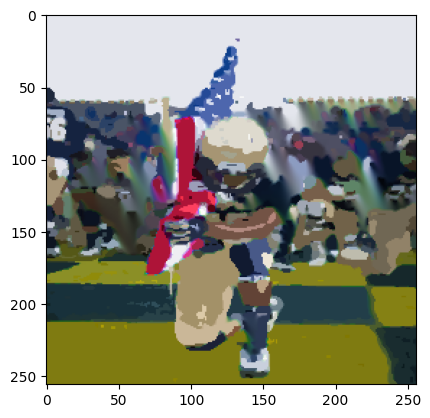

In [ ]:
# 1. Initialize recovery image and list to track cluster sizes for sorting
imRecover = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
imRecover[:] = (0, 0, 255)
clusters_to_draw = []

def sample_cubic_bezier(p0, p1, p2, p3, n_samples=24):
    pts = []
    n_samples = max(2, int(n_samples))
    for t in np.linspace(0.0, 1.0, n_samples):
        a = (1 - t) ** 3
        b = 3 * (1 - t) ** 2 * t
        c = 3 * (1 - t) * t ** 2
        d = t ** 3
        p = a * p0 + b * p1 + c * p2 + d * p3
        rr = int(round(p[0]))
        cc = int(round(p[1]))
        pts.append([cc, rr])
    return pts

# 2. Read the file once to collect all shapes and their data
with open("imComp.txt", "r") as f:
    current_cluster = None

    for line in f:
        l = line.strip().split(';')
        if len(l) == 0 or l[0] == '':
            continue

        if l[0] == 'C':
            color = np.array([int(i) for i in l[1].split(',')])
            current_cluster = {'color': color, 'pts': []}
            clusters_to_draw.append(current_cluster)

        elif l[0] == 'S' and current_cluster is not None:
            # S;degree;knots;ctrl_row;ctrl_col;
            k = int(l[1])
            t = np.array([float(v) for v in l[2].split(',')], dtype=float)
            cx = np.array([float(v) for v in l[3].split(',')], dtype=float)
            cy = np.array([float(v) for v in l[4].split(',')], dtype=float)

            tck = (t, [cx, cy], k)

            n_samples = max(32, int(2 * len(cx)))
            rows, cols = splev(np.linspace(0.0, 1.0, n_samples, endpoint=False), tck)

            for r, c in zip(rows, cols):
                rr = int(round(r))
                cc = int(round(c))
                current_cluster['pts'].append([cc, rr])

        elif l[0] == 'B' and current_cluster is not None:
            # Backward compatibility for Bezier files
            p0 = np.array([float(v) for v in l[1].split(',')])
            p1 = np.array([float(v) for v in l[2].split(',')])
            p2 = np.array([float(v) for v in l[3].split(',')])
            p3 = np.array([float(v) for v in l[4].split(',')])

            chord = np.linalg.norm(p3 - p0)
            n_samples = max(8, int(chord * 1.5))
            current_cluster['pts'].extend(sample_cubic_bezier(p0, p1, p2, p3, n_samples=n_samples))

        elif l[0] == 'P' and current_cluster is not None:
            # Backward compatibility for polynomial files
            startPt = int(l[1])
            poly_coeffs = [float(i) for i in l[2].split(',')]
            p = np.poly1d(poly_coeffs)
            endPt = int(l[3])

            step = 1 if endPt >= startPt else -1
            for r in range(startPt, endPt + step, step):
                c = int(round(p(r)))
                current_cluster['pts'].append([c, r])

        elif l[0] == 'V' and current_cluster is not None:
            # Backward compatibility for vertical-line files
            r_start, c_start = [int(kv) for kv in l[1].split(',')]
            r_end, c_end = [int(kv) for kv in l[2].split(',')]

            steps = max(abs(r_end - r_start), abs(c_end - c_start))
            if steps > 0:
                for s in range(steps + 1):
                    rr = int(r_start + s * (r_end - r_start) / steps)
                    cc = int(c_start + s * (c_end - c_start) / steps)
                    current_cluster['pts'].append([cc, rr])

# 3. Painter's algorithm: draw larger clusters first
clusters_to_draw.sort(key=lambda x: len(x['pts']), reverse=True)

# 4. Draw
for cluster in clusters_to_draw:
    if len(cluster['pts']) > 2:
        polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(imRecover, [polygon_points], color=cluster['color'].tolist())

# 5. Enforce coverage
# Track painted coverage
painted = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

# Draw pass
for cluster in clusters_to_draw:
    if len(cluster['pts']) > 2:
        polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(imRecover, [polygon_points], color=cluster['color'].tolist())
        cv2.fillPoly(painted, [polygon_points], color=1)

# Enforce minimum coverage
min_coverage = 0.9
coverage = float(np.mean(painted))
print(f"paint coverage: {coverage:.4f}")

if coverage < min_coverage:
    # Fallback: fill unpainted pixels from nearest painted neighbors
    H, W = painted.shape
    for _ in range(5):
        changed = False
        for r in range(H):
            for c in range(W):
                if painted[r, c] == 0:
                    vals = []
                    for dr in (-1, 0, 1):
                        for dc in (-1, 0, 1):
                            rr, cc = r + dr, c + dc
                            if 0 <= rr < H and 0 <= cc < W and painted[rr, cc] == 1:
                                vals.append(imRecover[rr, cc])
                    if vals:
                        imRecover[r, c] = np.mean(vals, axis=0).astype(np.uint8)
                        painted[r, c] = 1
                        changed = True
        if not changed:
            break

    coverage = float(np.mean(painted))
    print(f"coverage after repair: {coverage:.4f}")

# Optional hard fail if still too low
assert coverage >= min_coverage, f"Coverage too low: {coverage:.4f}"

plt.imshow(cv2.cvtColor(imRecover, cv2.COLOR_HSV2RGB))
plt.show()



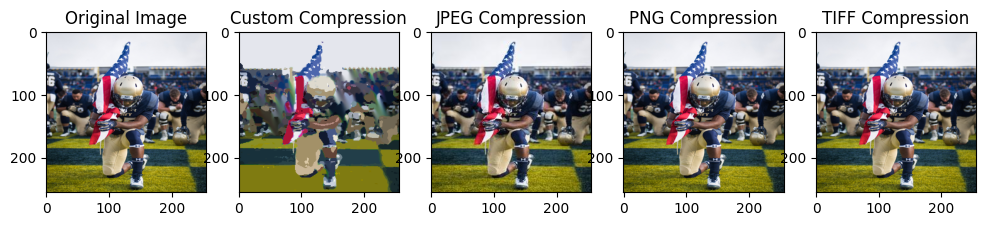

In [20]:
imj = cv2.imread('test.jpg')
imp = cv2.imread('test.png')
imt = cv2.imread('test.tiff')
f, axarr = plt.subplots(1,5, figsize=(12, 6))
axarr[0].imshow(chosenImage[...,::-1])
axarr[0].title.set_text('Original Image')
axarr[1].imshow(cv2.cvtColor(imRecover, cv2.COLOR_HSV2RGB))
axarr[1].title.set_text('Custom Compression')
axarr[2].imshow(imj[...,::-1])  # BGR to RGB for matplotlib
axarr[2].title.set_text('JPEG Compression')
axarr[3].imshow(imp[...,::-1])  # BGR to RGB for matplotlib
axarr[3].title.set_text('PNG Compression')
axarr[4].imshow(imt[...,::-1])  # BGR to RGB for matplotlib
axarr[4].title.set_text('TIFF Compression')